In [ ]:
# generate GT:
import pandas as pd
from pathlib import Path

# La ruta base 
ROOT_DIR = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish")

print("🔍 Llegint els CSVs i extraient els IDs únics...")
gt_dict = {}

# Busquem tots els *_raw.csv dins de les carpetes 'results'
for csv_path in sorted(ROOT_DIR.rglob("results/*_raw.csv")):
    # Agafem el nom de la carpeta "abuela" (ex: '10-01-53_0_compressed-r201-end')
    video_name = csv_path.parent.parent.name
    
    try:
        # Llegim només la columna 'track_id' 
        df = pd.read_csv(csv_path, usecols=['track_id'])
        
        # Traiem els valors nuls (si n'hi ha) i ho passem a llista d'enters ordenats
        unique_ids = sorted(df['track_id'].dropna().astype(int).unique().tolist())
        gt_dict[video_name] = unique_ids
        
    except Exception as e:
        print(f"⚠️ Error llegint {csv_path.name}: {e}")

# =========================================================
# 🖨️ IMPRIMIR EL DICCIONARI LLEST PER COPIAR I ENGANXAR
# =========================================================
print("\n" + "="*70)
print("📋 COPIA I ENGANXA AQUEST BLOC AL TEU CODI:")
print("="*70 + "\n")

print('GROUND_TRUTH_RETALLS = {')
print('    "2025_08_21": {')

for video, ids in gt_dict.items():
    if not ids:
        # Si per algun motiu el tracker no ha vist cap peix
        print(f'        "{video}": {{}}, # ⚠️ CAP PEIX DETECTAT')
        continue
        
    # Creem l'string del diccionari intern, ex: 1: "", 2: "", 3: ""
    ids_str = ", ".join([f'{i}: "None"' for i in ids])
    
    print(f'        "{video}": {{{ids_str}}},')

print('    }')
print('}')

🔍 Llegint els CSVs i extraient els IDs únics...

📋 COPIA I ENGANXA AQUEST BLOC AL TEU CODI:

GROUND_TRUTH_RETALLS = {
    "2025_08_21": {
        "10-01-53_0_compressed-r201-end": {-1: "None", 1: "None", 3: "None", 4: "None", 10: "None", 11: "None", 13: "None", 18: "None", 19: "None", 20: "None", 31: "None", 32: "None"},
        "10-07-59_0-r50-end": {-1: "None", 1: "None", 2: "None", 3: "None", 5: "None", 6: "None", 9: "None", 12: "None", 13: "None", 14: "None", 15: "None", 16: "None", 18: "None", 19: "None", 20: "None", 21: "None", 22: "None", 24: "None", 27: "None", 28: "None"},
        "10-09-31_0-r0-344": {1: "None", 4: "None", 5: "None", 7: "None", 8: "None", 9: "None", 10: "None", 12: "None", 16: "None", 17: "None"},
        "10-09-31_0-r398-end": {-1: "None", 1: "None", 2: "None", 4: "None", 5: "None", 7: "None", 8: "None", 9: "None", 12: "None", 13: "None", 14: "None"},
        "10-11-02_0-r0-244": {-1: "None", 1: "None", 2: "None", 3: "None", 7: "None", 9: "None", 14: "None"}

In [1]:
GROUND_TRUTH_RETALLS = {
    "2025_08_21": {
        
        # ---------------------------------------------------------
        # VÍDEOS RETALLATS (Noves assignacions d'ID necessàries)
        # ---------------------------------------------------------
        "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 
                                           11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 
                                           31: "no_mark", 32: "red"},
        
        "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 
                               5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 
                               13: "None", 14: "None", 15: "red", 16: "red", 
                               18: "red", 19: "red", 20: "red", 21: "no_mark", 
                               22: "None", 24: "red", 27: "no_mark", 28: "red"},
        
        
        "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 
                              9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},
        

        
        "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 
                                5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 
                                12: "red", 13: "red", 14: "red"},
        
        
        "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 
                              3: "red", 7: "no_mark", 9: "None", 14: "red"},
        

        "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 
                                8: "None", 10: "red", 14: "no_mark"},
  
        
        "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 
                                6: "red", 7: "None", 10: "red", 
                                12: "red", 14: "None", 15: "no_mark"},
        # L'1 es transfereix el 15 tambe (he deixat com a gt el peix amb el que es queda al final)
        
        
        "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 
                              9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 
                              15: "None", 16: "None", 17: "no_mark", 18: "red"},
        # El 6 al final passa del red al no_mask...
        
        "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
        
        
        
        "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 
                                          7: "no_mark", 10: "red", 11: "None", 
                                          12: "red", 17: "red", 18: "red"},
        

        
        "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
    
        
        "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},

        "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 
                                        2: "no_mark", 3: "no_mark", 4: "red"},
        
        "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark",
                                  3: "red", 5: "None"},

        "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 
                         3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
        
        
        "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 
                         8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 
                         22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 
                         30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 
                         47: "no_mark", 49: "black"},
        # igual s ha de  revisar...
        
                
        "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 
                                          7: "None", 9: "red", 11: "None", 13: "black"},
        
        
        "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
        
                
        "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
        
        "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
        # no tenc clar si el 2 i el 3 es giren
        
        "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"},
        
        
        
        # ---------------------------------------------------------
        # VÍDEOS QUE NO S'HAN RETALLAT (Es manté el GT original)
        # ---------------------------------------------------------
        # '10-22-00_1_compressed': {1: "red", 2: "no_mark", 3: "red"},
        # '10-24-19_0': {1: "red", 8: "red", 9: "red"},
        # '10-25-04_1': {1: "red", 2: "no_mark", 3: "no_mark", 5: "red", 6: "no_mark", 12: "red", 14: "red", 15: "no_mark"},
        # '10-36-31_0': {1: "red", 5: "no_mark", 12: "red", 15: "no_mark", 17: "red", 18: "red", 19: "no_mark", 20: "red", 23: "no_mark", 25: "red", 27: "red", 28: "no_mark"},
        # '13-06-51_1': {1: "red", 2: "black", 4: "black", 5: "no_mark"},
        # '13-10-19_0': {1: "red", 3: "black", 9: "no_mark", 11: "black", 14: "black", 18: "red", 20: "black", 21: "black", 26: "no_mark", 28: "no_mark", 31: "red", 32: "red", 40: "red", 44: "red", 45: "red"},
        # '13-11-04_1': {1: "red", 2: "black", 8: "no_mark"},
        # '13-23-02_1_compressed': {1: "red", 2: "black", 3: "no_mark", 5:"no_mark", 7: "no_mark", 8: "error", 9: "error", 10: "red", 13: "red"},
        # '13-24-34_1_compressed': {1: "black", 2: "no_mark", 3: "red", 4: "no_mark", 5: "error", 6: "no_mark", 7: "black", 10: "error"},
        # '13-25-26_0_compressed': {1: "red", 2: "red", 4: "red", 5: "red", 10: "red", 12: "red", 13: "red", 16: "red", 17: "red", 23: "red", 36: "red", 39: "red"},
        # '13-26-05_1_compressed': {1: "red", 2: "red", 3: "red", 6: "red", 7: "red", 15: "red", 19: "red", 20: "red"},
        # '13-27-37_1_compressed': {1: "red", 5: "red"},
        # '13-28-29_0_compressed': {1: "red", 2: "red", 4: "red", 8: "red", 10: "red", 13: "red", 14: "red", 18: "red", 20: "red", 30: "red"},
        # '13-29-08_1_compressed': {1: "red", 2: "red", 7: "red", 8: "red", 10: "red"}
    }
}

In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
import results_analysis_utils as rutils
from IPython.display import display, Markdown
pd.set_option('display.max_columns', 100)

# EXECUTE COPY TO LOCAL DISK PRIMER!!!!!

%load_ext autoreload
%autoreload 2

# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 
plt.rcParams['savefig.dpi'] = 200

# ===================================================================
# 1. DICCIONARIOS DE GROUND TRUTH
# ===================================================================
peix_measures = {
    "lubina0": 31.5, "fish_1": 19.4, "caballa": 28.9, "fish_3": 21.6,
    "llobarro": 33.5, "ochoa_no_cinta": 30.5, "ochoa_cinta": 33.5, 
    "ochoa_petita": 30.5, "llobarro_vermell": 29.1, "error": -100, "None": -100,
    "red":29.1, "black":26.6, "no_mark":32.3
}

# (Diccionario inverso para buscar el nombre de la especie sabiendo la medida en 1_peix)
reverse_peix_measures = {v: k for k, v in peix_measures.items()}

In [3]:


initialized = False
if not initialized:
    single_fish_gt = {
    "2025_08_21": 29.1
    }
    
    multiple_fish_gt= {
        "2025_08_21": {
            
            # ---------------------------------------------------------
            # VÍDEOS RETALLATS (Noves assignacions d'ID necessàries)
            # ---------------------------------------------------------
            "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 
                                            11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 
                                            31: "no_mark", 32: "red"},
            
            "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 
                                5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 
                                13: "None", 14: "None", 15: "red", 16: "red", 
                                18: "red", 19: "red", 20: "red", 21: "no_mark", 
                                22: "None", 24: "red", 27: "no_mark", 28: "red"},
            
            
            "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 
                                9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},
            

            
            "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 
                                    5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 
                                    12: "red", 13: "red", 14: "red"},
            
            
            "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 
                                3: "red", 7: "no_mark", 9: "None", 14: "red"},
            

            "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 
                                    8: "None", 10: "red", 14: "no_mark"},
    
            
            "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 
                                    6: "red", 7: "None", 10: "red", 
                                    12: "red", 14: "None", 15: "no_mark"},
            # L'1 es transfereix el 15 tambe (he deixat com a gt el peix amb el que es queda al final)
            
            
            "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 
                                9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 
                                15: "None", 16: "None", 17: "no_mark", 18: "red"},
            # El 6 al final passa del red al no_mask...
            
            "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
            
            
            
            "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 
                                            7: "no_mark", 10: "red", 11: "None", 
                                            12: "red", 17: "red", 18: "red"},
            
  
            "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
        
            
            "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},

            "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 
                                            2: "no_mark", 3: "no_mark", 4: "red"},
            
            "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark",
                                    3: "red", 5: "None"},

            "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 
                            3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
            
            
            "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 
                            8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 
                            22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 
                            30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 
                            47: "no_mark", 49: "black"},
            # igual s ha de  revisar...
            

            "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 
                                            7: "None", 9: "red", 11: "None", 13: "black"},
            
            
            "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
            
                    
            "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
            
            "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
            # no tenc clar si el 2 i el 3 es giren
            
            "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"} 
        }
    }

    #===================================================================
    # 2. PARÁMETROS Y RUTAS
    # ===================================================================
    # Ruta base donde están todas las carpetas de días
    BASE_DIR = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_2/")

    # Carpeta SOLO para los resultados globales (se crea si no existe)
    OUTPUT_DIR_GLOBAL = BASE_DIR / "aggregated_data"
    os.makedirs(OUTPUT_DIR_GLOBAL, exist_ok=True)

    ASPECT_RATIO_THR = 3.0
    ANGLE_THR = 30.0

    ALL_DAYS = list(set(list(single_fish_gt.keys()) + list(multiple_fish_gt.keys())))

    global_single_dfs = []
    global_multi_dfs = []

    # ===================================================================
    # 3. BUCLE MAESTRO
    # ===================================================================
    cprint(f"🚀 INICIANDO PIPELINE DE AGREGACIÓN PARA {len(ALL_DAYS)} DÍAS", "white", "on_blue", attrs=["bold"])

    for day_code in sorted(ALL_DAYS):
        cprint(f"\n" + "="*50, "cyan")
        cprint(f"📅 PROCESANDO DÍA: {day_code}", "cyan", attrs=["bold"])
        
        day_folder = BASE_DIR / day_code
        
        if not day_folder.exists():
            cprint(f"⚠️ La carpeta no existe. Busqué en: {day_folder}", "yellow")
            continue

        # Lista para guardar todos los datos de ESTE día
        day_dfs = []

        # ---------------------------------------------------------------
        # A) PROCESAR SINGLE FISH
        # ---------------------------------------------------------------
        dir_single = day_folder / "single_fish"
        
        if dir_single.exists() and day_code in single_fish_gt:
            cprint(f"\n🐟 Buscando SINGLE FISH en {dir_single}...", "magenta")
            df_single = rutils.aggregate_results_from_root_new(dir_single, day_code, output_csv_path=dir_single,results_foldername="results")
            
            if not df_single.empty:
                medida = single_fish_gt[day_code]
                especie = reverse_peix_measures.get(medida, "unknown_single_fish")
                
                df_single["gt"] = medida
                df_single["especie_gt"] = especie
                df_single["abs_error_cm"] = abs((df_single["filtered_length"] * 100) - medida)
                df_single["failure_reason"] = np.nan
                df_single['unique_track'] = df_single['video_day'].astype(str) + "/" + df_single['video_name'].astype(str) + "/" + df_single['track_id'].astype(str)
                df_single["scenario"] = "single_fish"
                
                out_single = dir_single / f"{day_code}_single_fish_agg.csv"
                df_single.to_csv(out_single, index=False)
                
                global_single_dfs.append(df_single)
                day_dfs.append(df_single) # Añadimos al saco del día
                cprint(f"   ✅ Single Fish completado. Guardado en: {out_single}", "green")
        else:
            if not dir_single.exists():
                cprint(f"   ℹ️ No hay carpeta 'single_fish' para este día.", "dark_grey")
        
        # ---------------------------------------------------------------
        # B) PROCESAR MULTIPLE FISH
        # ---------------------------------------------------------------
        dir_multi = day_folder / "multiple_fish"  
        
        if dir_multi.exists() and day_code in multiple_fish_gt:
            cprint(f"\n🐠🐠 Buscando MULTIPLE FISH en {dir_multi}...", "magenta")
            df_multi_raw = rutils.aggregate_results_from_root_new(dir_multi, day_code, output_csv_path=dir_multi,results_foldername="results")
            
            if not df_multi_raw.empty:
                df_multi_raw['track_id'] = pd.to_numeric(df_multi_raw['track_id'], errors='coerce').fillna(-1).astype(int)
                               
                
                df_multi, huerfanos = rutils.inject_ground_truth(
                    df_multi_raw, 
                    {day_code: multiple_fish_gt[day_code]}, 
                    peix_measures, 
                    drop_unlabeled=False
                )
                df_missing = df_multi[df_multi['gt'].isna()]
                if not df_missing.empty:
                    cprint(f"\n🔍 DETALLE DE LOS TRACKS SIN GROUND TRUTH (Total frames: {len(df_missing)}):", "yellow", attrs=["bold"])
                    missing_summary = df_missing.groupby('video_name')['track_id'].unique()
                    
                    for video, ids in missing_summary.items():
                        print(f"   🎬 Vídeo: '{video}'  --> IDs perdidos: {ids}")
                # 👆 FIN DEL BLOQUE NUEVO 👆

 
                df_multi["scenario"] = "multiple_fish"
                
                out_multi = dir_multi / f"{day_code}_multiple_fish_agg.csv"
                df_multi.to_csv(out_multi, index=False)
                
                global_multi_dfs.append(df_multi)
                day_dfs.append(df_multi) # Añadimos al saco del día
                cprint(f"   ✅ Multiple Fish completado. Guardado en: {out_multi}", "green")
        else:
            if not dir_multi.exists():
                cprint(f"   ℹ️ No hay carpeta 'multiple_fish' para este día.", "dark_grey")

        # ---------------------------------------------------------------
        #  C) GUARDAR EL AGREGADO GLOBAL DEL DÍA EN LA RAÍZ
        # ---------------------------------------------------------------
        if day_dfs:
            df_day_all = pd.concat(day_dfs, ignore_index=True)
            out_day = day_folder / f"{day_code}_raw_aggregated.csv"
            df_day_all.to_csv(out_day, index=False)
            cprint(f"\n   📁 AGREGADO DEL DÍA CREADO: {out_day}", "cyan", attrs=["bold"])
            
            
    # ===================================================================
    # 4. CREAR LOS DATASETS MASIVOS GLOBALES
    # ===================================================================
    cprint("\n" + "="*50, "blue")
    cprint(f"🌍 GENERANDO DATASETS GLOBALES EN: {OUTPUT_DIR_GLOBAL.name}", "white", "on_blue", attrs=["bold"])

    df_master_single = pd.DataFrame()
    df_master_multi = pd.DataFrame()

    # 1. Guardar el global exclusivo de Single Fish
    if global_single_dfs:
        df_master_single = pd.concat(global_single_dfs, ignore_index=True)
        out_single_global = OUTPUT_DIR_GLOBAL / "ALL_single_fish_all_days.csv"
        df_master_single.to_csv(out_single_global, index=False)
        cprint(f"📦 Guardado: {out_single_global.name} ({len(df_master_single)} frames)", "cyan")

    # 2. Guardar el global exclusivo de Multiple Fish
    if global_multi_dfs:
        df_master_multi = pd.concat(global_multi_dfs, ignore_index=True)
        out_multi_global = OUTPUT_DIR_GLOBAL / "ALL_multiple_fish_all_days.csv"
        df_master_multi.to_csv(out_multi_global, index=False)
        cprint(f"📦 Guardado: {out_multi_global.name} ({len(df_master_multi)} frames)", "cyan")

    # 3. Guardar el SÚPER MEGA DATASET (Todos los días + Single + Multiple)
    if not df_master_single.empty or not df_master_multi.empty:
        # Juntamos los dos mundos
        df_master_all = pd.concat([df_master_single, df_master_multi], ignore_index=True)
        
        # ⚡ Aplicamos tu clasificador vectorial (bordes, 3D, aspect ratio...) a toda la base de datos de golpe
        df_master_all = rutils.assign_failure_reasons(df_master_all, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
        
        out_master = OUTPUT_DIR_GLOBAL / "MASTER_all_fish_all_days.csv"
        df_master_all.to_csv(out_master, index=False)

🚀 INICIANDO PIPELINE DE AGREGACIÓN PARA 1 DÍAS

📅 PROCESANDO DÍA: 2025_08_21

🐟 Buscando SINGLE FISH en /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/single_fish...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/single_fish
📂 Encontrados 35 archivos de resultados crudos.

📊 TOTAL AGREGADO: 16380 líneas de datos.
   ✅ Single Fish completado. Guardado en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/single_fish/2025_08_21_single_fish_agg.csv

🐠🐠 Buscando MULTIPLE FISH en /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish
📂 Encontrados 21 archivos de resultados crudos.

📊 TOTAL AGREGADO: 9831 líneas de datos.
✅ Ground Truth inyectado. Vídeos únicos: 21
   🐟 Tracks CON Ground Truth: 167
   🎉 ¡Todos los tracks tienen su Ground Truth!
   ✅ Multiple Fish completado. Guardado en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/

In [4]:
df_raw_agg = df_multi_raw
df_raw_agg

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,255,2,1,False,False,True,3.370370,True,True,[],[ 0.90109 -0.045347 -0.43126],-25.260157,-2.751512,0.269733,0.256492,0.267130,33.5,7.850764,23.435117,1.929511
1,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,127,1,1,False,False,True,3.896552,True,True,[],[ -0.011928 0.067009 0.99768],12.120524,-1.571899,0.827815,0.303424,0.305027,33.5,3.157569,9.425578,1.964071
2,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,255,2,1,False,False,True,3.730769,True,True,[],[ 0.93595 -0.071721 -0.34476],-16.184413,-3.042739,0.286138,0.272680,0.277277,33.5,6.232012,18.603020,1.943986
3,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,127,1,1,False,False,True,3.673619,True,True,[],[ 0.98285 0.0039971 0.18438],13.104982,0.956247,0.304476,0.300675,0.293510,33.5,3.432468,10.246174,1.961672
4,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_2,0,255,2,1,False,False,True,3.629630,True,True,[],[ 0.96537 -0.063025 -0.25314],-14.494717,-3.537626,0.261962,0.262073,0.277748,33.5,7.292714,21.769294,1.945008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9826,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_209,0,127,9,1,False,False,True,3.756264,True,True,[],[ 0.716 0.39683 0.57434],34.480758,27.980829,0.314987,0.313961,0.310101,33.5,2.103900,6.280298,1.607512
9827,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,255,14,1,False,False,True,3.710797,True,True,[],[ 0.94621 0.18708 -0.26397],-15.434967,11.138975,0.274666,0.274631,0.270029,33.5,6.036921,18.020659,1.680929
9828,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,127,9,1,False,False,True,4.247777,True,True,[],[ 0.70012 0.40641 0.58708],34.512254,29.316305,0.332776,0.317733,0.312440,33.5,1.726670,5.154238,1.609569
9829,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_211,0,255,14,1,False,False,True,3.639830,True,True,[],[ 0.91769 0.21707 -0.33276],-18.585511,13.240168,0.291738,0.291588,0.282441,33.5,4.341181,12.958749,1.693683


### MULTIPLE FISH

#### LOAD AND SUMMARY


In [5]:
FOLDER_TO_ANALYSE="/home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/"
group = "multiple_fish"
print(FOLDER_TO_ANALYSE)
csv_path = os.path.join(FOLDER_TO_ANALYSE,group,
                        day_code+"_"+group+"_agg.csv")



context_label = f"{day_code} - {group.upper()}"
cprint(f"👉 WORKING ON: {context_label}", "white", "on_blue", attrs=["bold"])


csv_out_path = os.path.join(FOLDER_TO_ANALYSE,group)

cprint(f"Reading csv from {csv_path}", "yellow")

# 1. Load aggregated raw csv:
df_raw_agg = pd.read_csv(csv_path)

# 1. Load aggregated raw csv:
df_raw_agg = pd.read_csv(csv_path)

df_raw_agg = rutils.assign_failure_reasons(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR
)

display(df_raw_agg.head()) 

print("DF NUMERIC SUMMARY: ")
display(df_raw_agg.describe())
print("\n ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")


print("DF CATEGORICAL SUMMARY: ")
categorical_cols = df_raw_agg.select_dtypes(include=['object', 'category'])
display(categorical_cols.describe())
summary = pd.DataFrame({
    'unique_values': categorical_cols.nunique(),
    'most_frequent': categorical_cols.mode().iloc[0],
    'freq': categorical_cols.apply(lambda x: x.value_counts().iloc[0]),
    'missing': categorical_cols.isnull().sum()
})
display(summary)

print("\n ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

print("DF HEAD: ")
display(df_raw_agg.head())


/home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/
👉 WORKING ON: 2025_08_21 - MULTIPLE_FISH
Reading csv from /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish/2025_08_21_multiple_fish_agg.csv


,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,especie_gt,gt,failure_reason,abs_error_cm,unique_track,scenario
0,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,255,2,1,False,False,True,3.370370,True,True,[],[ 0.90109 -0.045347 -0.43126],-25.260157,-2.751512,0.269733,0.256492,0.267130,23.435117,1.929511,red,29.1,measured,3.450764,2025_08_21/10-37-15_1-r/2,multiple_fish
1,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,127,1,1,False,False,True,3.896552,True,True,[],[ -0.011928 0.067009 0.99768],12.120524,-1.571899,0.827815,0.303424,0.305027,9.425578,1.964071,no_mark,32.3,measured,1.957569,2025_08_21/10-37-15_1-r/1,multiple_fish
2,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,255,2,1,False,False,True,3.730769,True,True,[],[ 0.93595 -0.071721 -0.34476],-16.184413,-3.042739,0.286138,0.272680,0.277277,18.603020,1.943986,red,29.1,measured,1.832012,2025_08_21/10-37-15_1-r/2,multiple_fish
3,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,127,1,1,False,False,True,3.673619,True,True,[],[ 0.98285 0.0039971 0.18438],13.104982,0.956247,0.304476,0.300675,0.293510,10.246174,1.961672,no_mark,32.3,measured,2.232468,2025_08_21/10-37-15_1-r/1,multiple_fish
4,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_2,0,255,2,1,False,False,True,3.629630,True,True,[],[ 0.96537 -0.063025 -0.25314],-14.494717,-3.537626,0.261962,0.262073,0.277748,21.769294,1.945008,red,29.1,measured,2.892714,2025_08_21/10-37-15_1-r/2,multiple_fish


DF NUMERIC SUMMARY: 


,class_name,object_id,track_id,is_3D_complete,aspect_ratio,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,gt,abs_error_cm
count,9831.0,9831.000000,9831.000000,9831.000000,9831.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9146.000000,9431.000000,9831.000000,9431.000000
mean,0.0,197.903367,8.471468,0.968671,2.866659,26.732099,-23.594972,0.269751,0.222886,0.259728,24.542937,1.691944,28.617262,10.206313
std,0.0,65.698160,8.880567,0.174215,0.915696,34.177611,78.622508,0.518380,0.227308,0.075310,18.734383,0.277199,14.665082,24.530024
min,0.0,63.000000,-1.000000,0.000000,1.000000,-44.940296,-179.979487,-1.000000,-1.000000,0.000000,0.018969,0.766127,-100.000000,0.000000
25%,0.0,127.000000,2.000000,1.000000,2.178509,-1.000000,-37.938797,0.249337,0.220144,0.225336,11.999058,1.597888,29.100000,1.511547
50%,0.0,255.000000,6.000000,1.000000,2.889001,30.320937,-3.349485,0.298735,0.264512,0.265636,20.958141,1.755553,29.100000,3.645994
75%,0.0,255.000000,12.000000,1.000000,3.610299,55.142518,6.658715,0.384107,0.296852,0.297109,33.162587,1.847935,32.300000,8.753848
max,0.0,255.000000,49.000000,1.000000,6.080000,88.949472,179.936236,2.847319,1.632771,1.601690,387.394417,3.017367,32.300000,144.116025



 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
DF CATEGORICAL SUMMARY: 


,video_day,source_folder,video_name,frame_id,pointcloud_size_ok,overlapping_fish_ids,fish_direction,especie_gt,failure_reason,unique_track,scenario
count,9831,9831,9831,9831,9431,9831,8599,9831,9831,9831,9831
unique,1,21,21,615,2,83,8599,5,8,167,1
top,2025_08_21,13-05-55_0-r,13-05-55_0-r,frame_21,True,[],[ 0.71807 0.41123 0.56148],red,aspect_ratio_fail,2025_08_21/10-18-24_0_compressed-r47-end/7,multiple_fish
freq,9831,1522,1522,44,9146,6983,1,4481,3667,480,9831


,unique_values,most_frequent,freq,missing
video_day,1,2025_08_21,9831,0
source_folder,21,13-05-55_0-r,1522,0
video_name,21,13-05-55_0-r,1522,0
frame_id,615,frame_21,44,0
pointcloud_size_ok,2,True,9146,400
overlapping_fish_ids,83,[],6983,0
fish_direction,8599,[ 1 4.9518e-05 -0.00087814],1,1232
especie_gt,5,red,4481,0
failure_reason,8,aspect_ratio_fail,3667,0
unique_track,167,2025_08_21/10-18-24_0_compressed-r47-end/7,480,0



 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
DF HEAD: 


,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,especie_gt,gt,failure_reason,abs_error_cm,unique_track,scenario
0,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,255,2,1,False,False,True,3.370370,True,True,[],[ 0.90109 -0.045347 -0.43126],-25.260157,-2.751512,0.269733,0.256492,0.267130,23.435117,1.929511,red,29.1,measured,3.450764,2025_08_21/10-37-15_1-r/2,multiple_fish
1,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_0,0,127,1,1,False,False,True,3.896552,True,True,[],[ -0.011928 0.067009 0.99768],12.120524,-1.571899,0.827815,0.303424,0.305027,9.425578,1.964071,no_mark,32.3,measured,1.957569,2025_08_21/10-37-15_1-r/1,multiple_fish
2,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,255,2,1,False,False,True,3.730769,True,True,[],[ 0.93595 -0.071721 -0.34476],-16.184413,-3.042739,0.286138,0.272680,0.277277,18.603020,1.943986,red,29.1,measured,1.832012,2025_08_21/10-37-15_1-r/2,multiple_fish
3,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_1,0,127,1,1,False,False,True,3.673619,True,True,[],[ 0.98285 0.0039971 0.18438],13.104982,0.956247,0.304476,0.300675,0.293510,10.246174,1.961672,no_mark,32.3,measured,2.232468,2025_08_21/10-37-15_1-r/1,multiple_fish
4,2025_08_21,10-37-15_1-r,10-37-15_1-r,frame_2,0,255,2,1,False,False,True,3.629630,True,True,[],[ 0.96537 -0.063025 -0.25314],-14.494717,-3.537626,0.261962,0.262073,0.277748,21.769294,1.945008,red,29.1,measured,2.892714,2025_08_21/10-37-15_1-r/2,multiple_fish


#### RESULTS SUMMARY

##### FRAMES SUMMARY

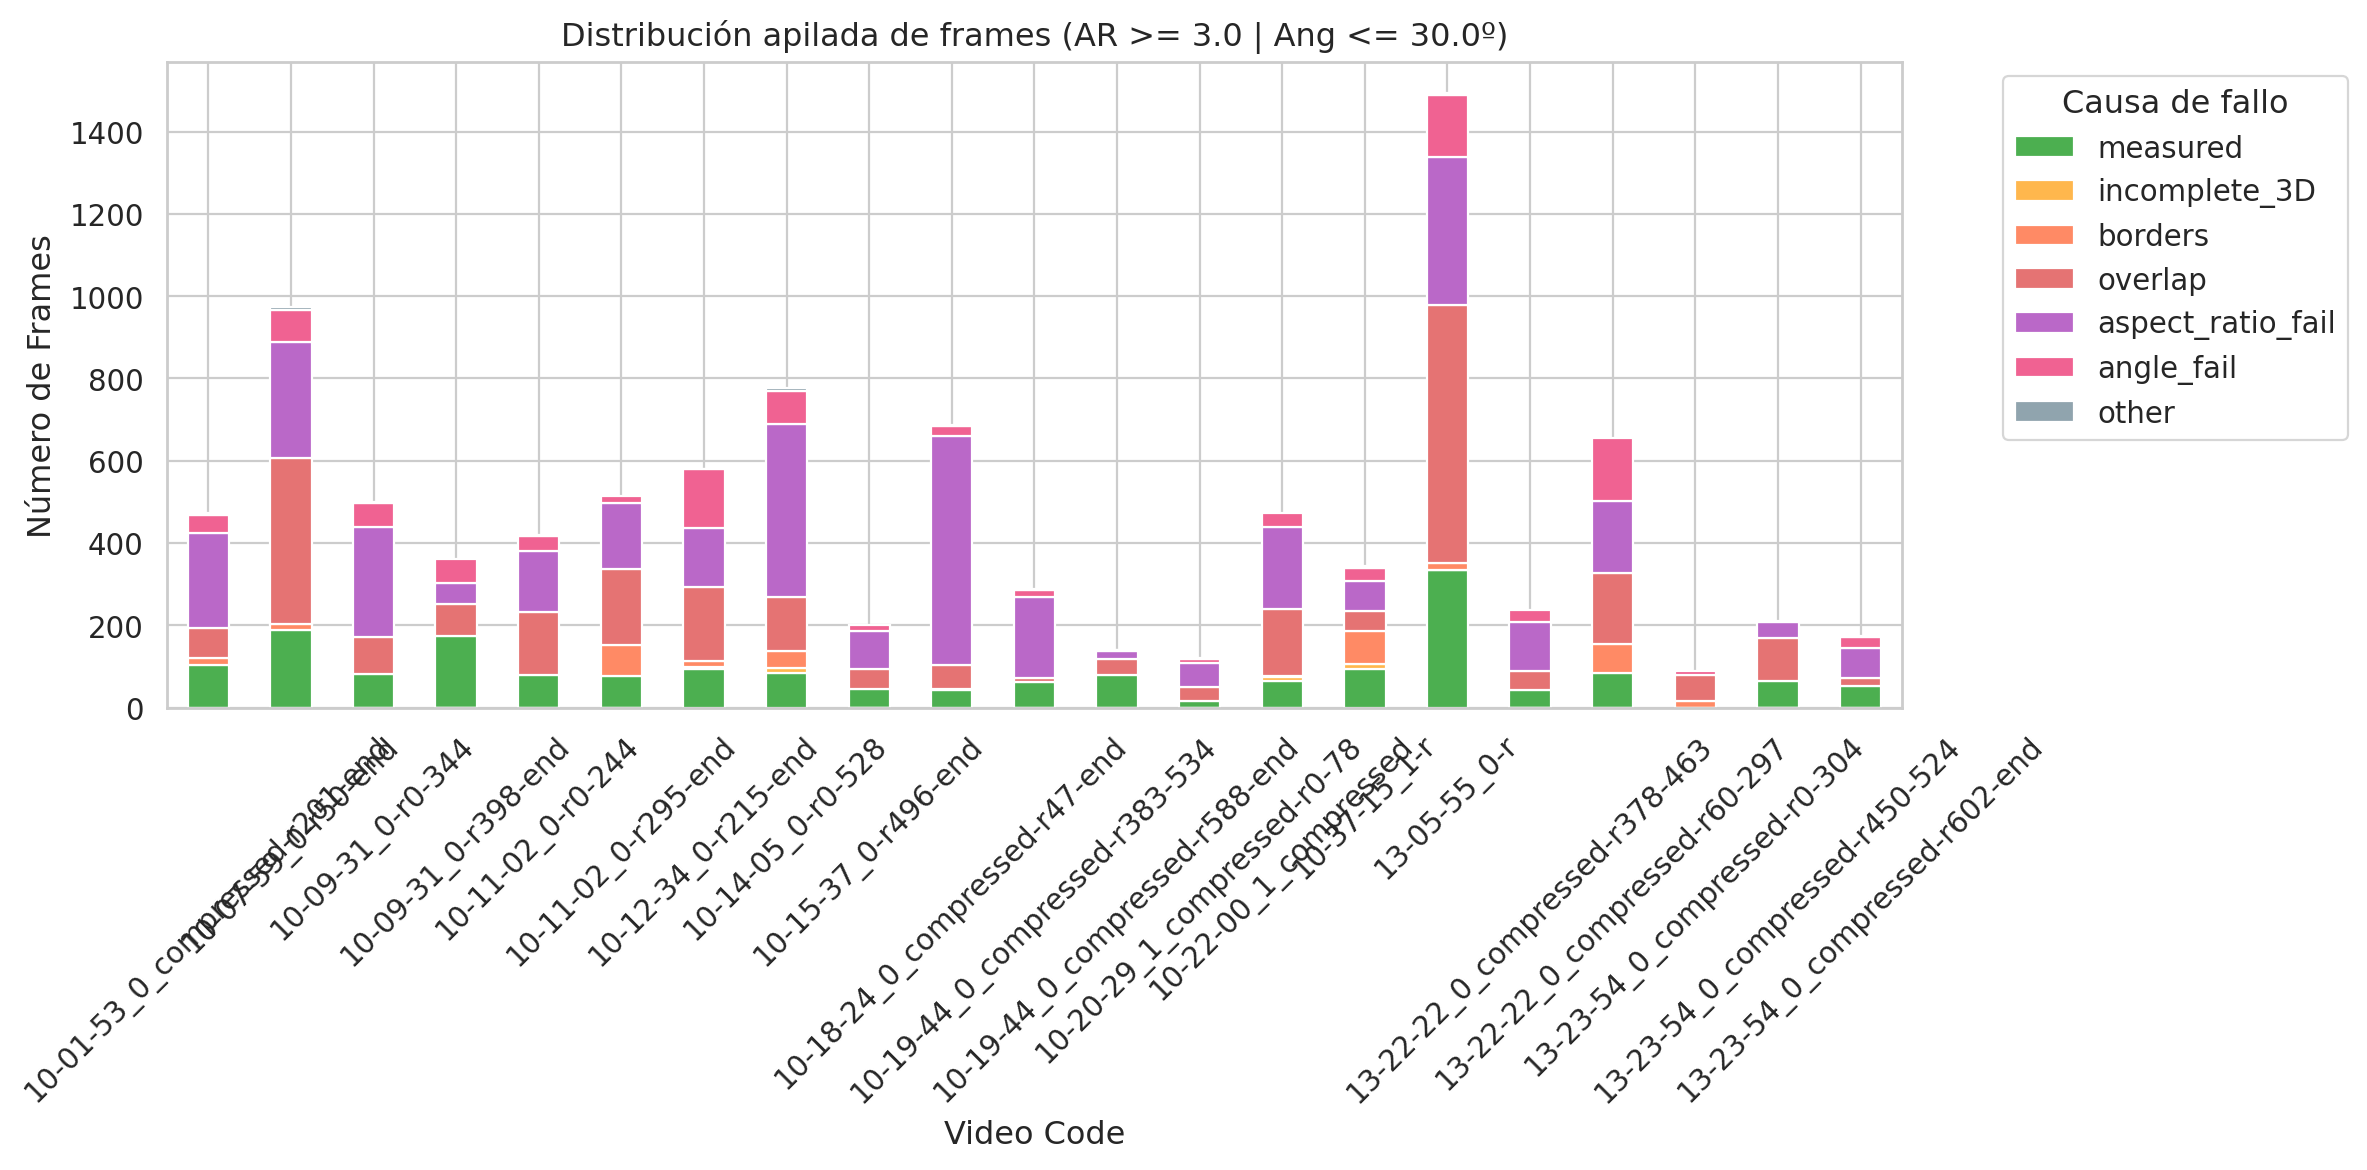

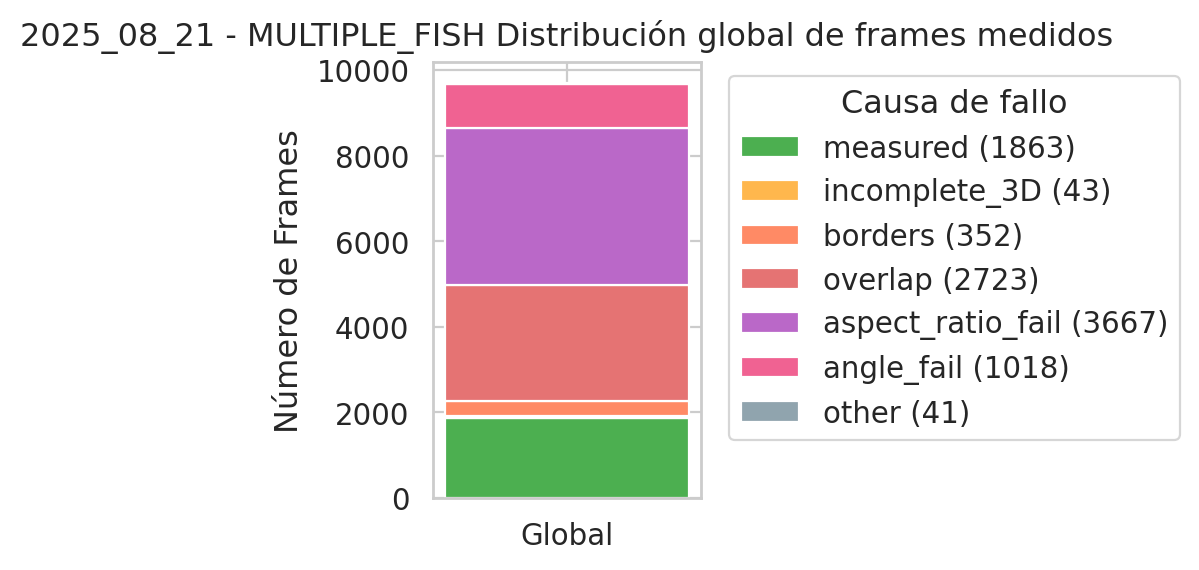


📊 TABLA 1: Distribución Global de Frames


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,1863,19.19
1,incomplete_3D,43,0.44
2,borders,352,3.63
3,overlap,2723,28.05
4,aspect_ratio_fail,3667,37.78
5,angle_fail,1018,10.49
6,other,41,0.42


In [6]:
stacked_frames = rutils.plot_frame_failures(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    figsize_video=(12,6), 
    figsize_global=(5,3), 
    show_global=True,
    context_label=context_label
)



##### TRACKS SUMMARY

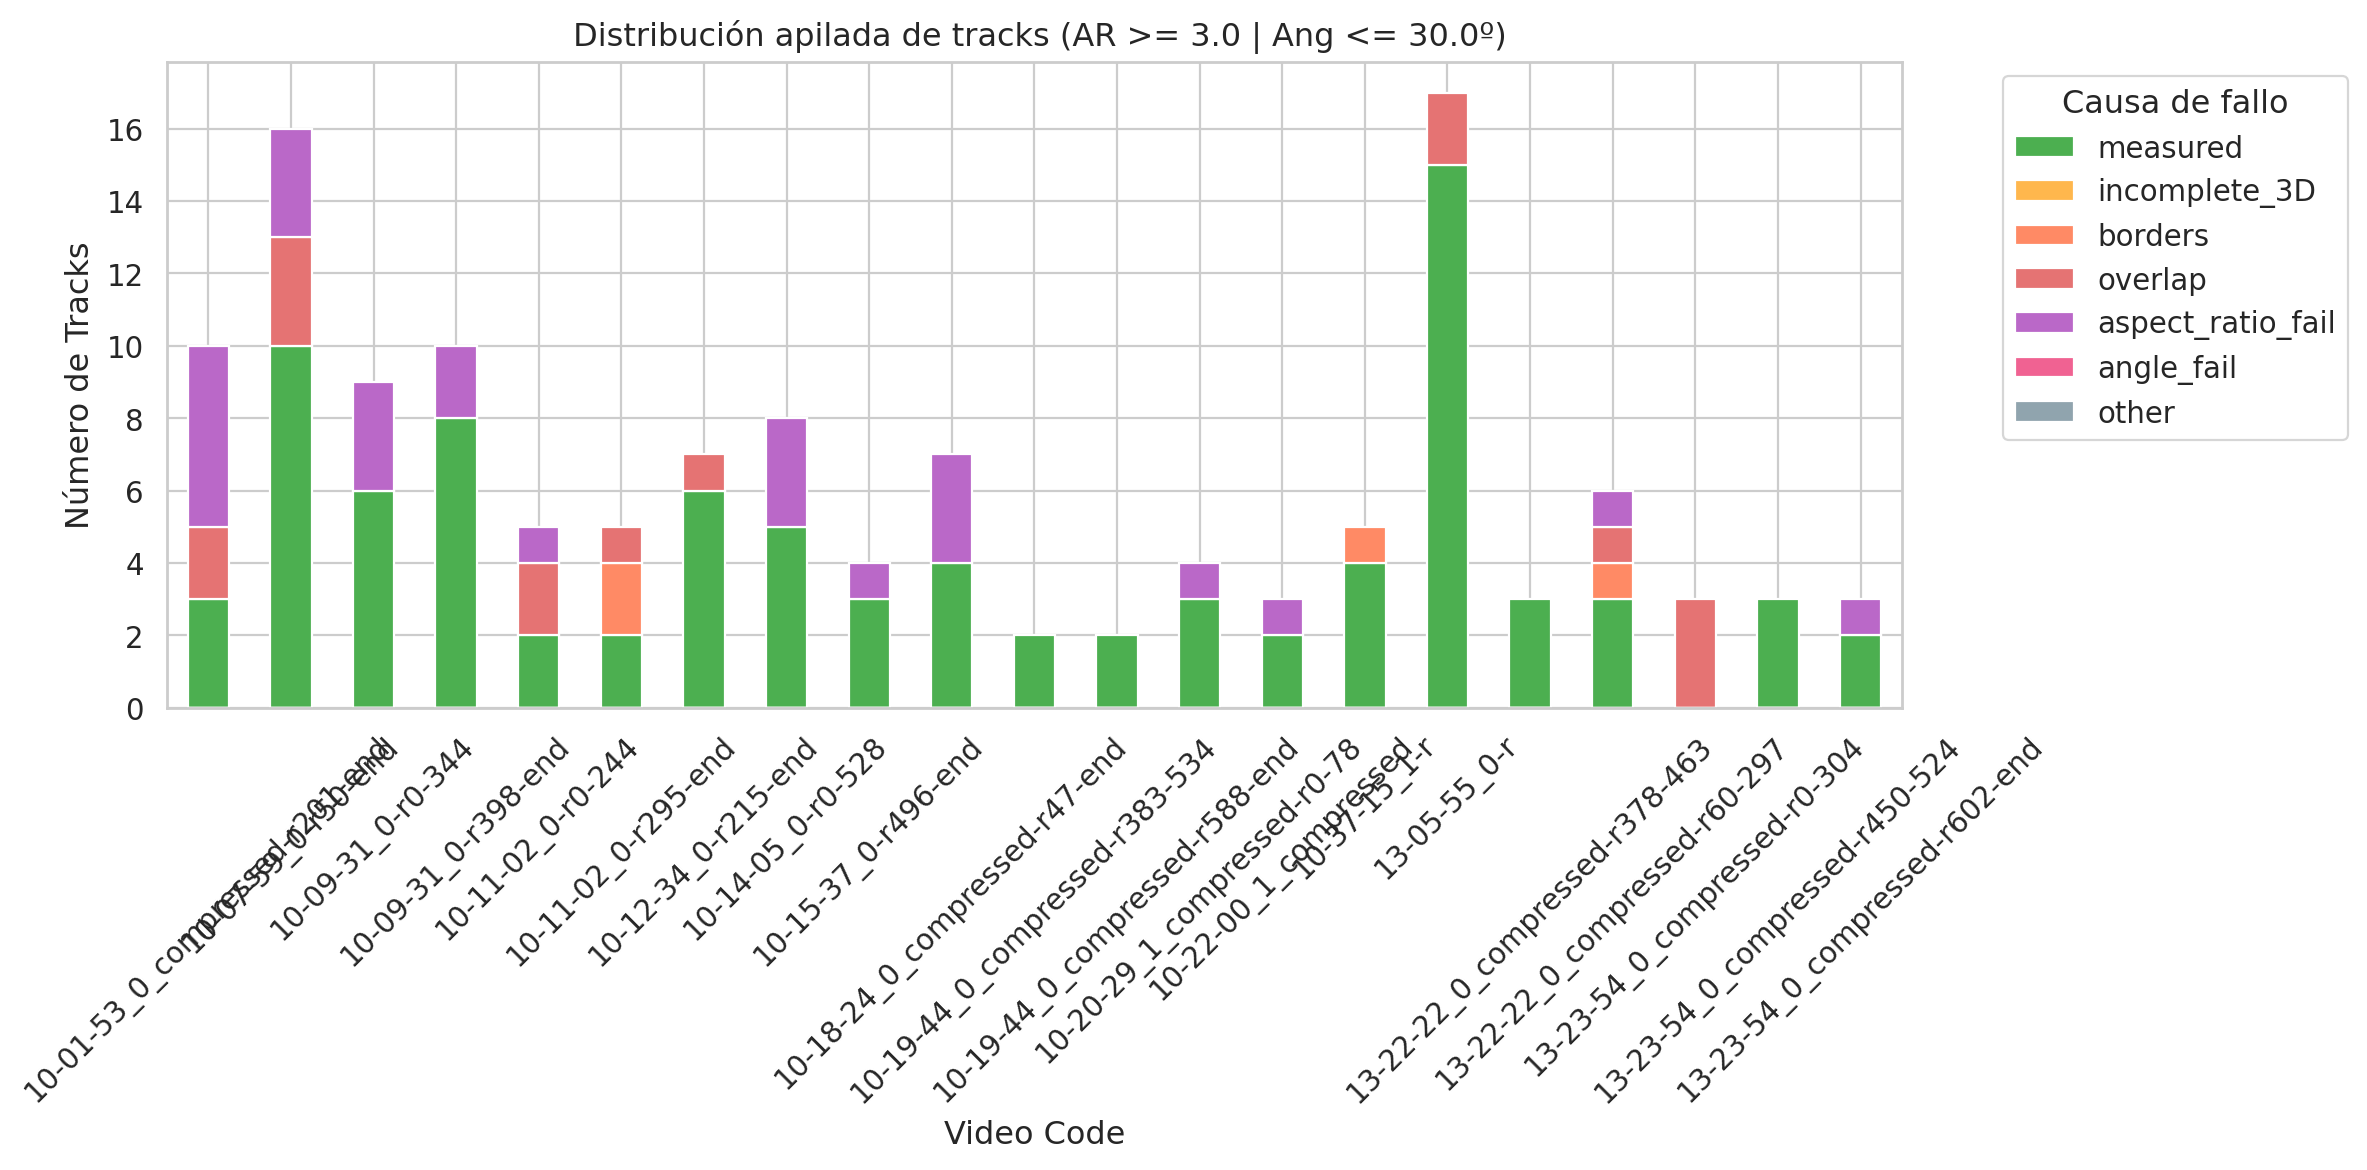

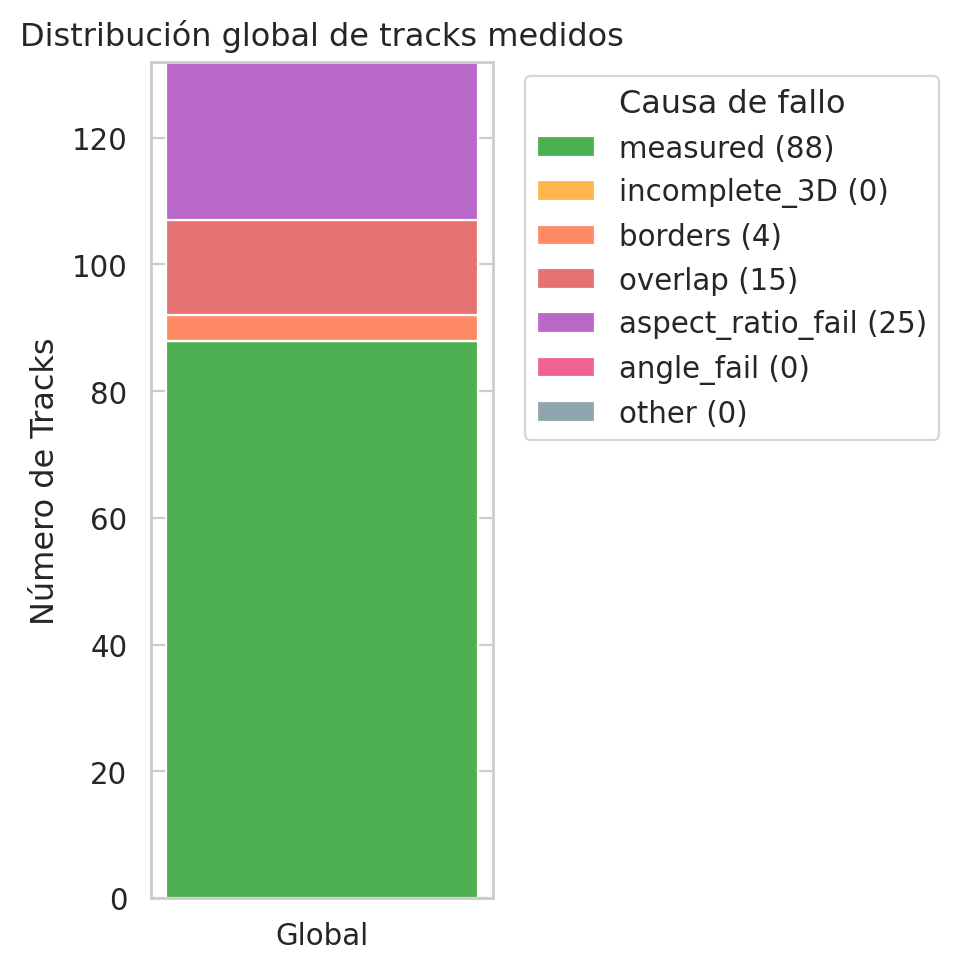


📊 TABLA 1: Distribución Global de Tracks


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,88,66.67
1,incomplete_3D,0,0.00
2,borders,4,3.03
3,overlap,15,11.36
4,aspect_ratio_fail,25,18.94
5,angle_fail,0,0.00
6,other,0,0.00



📊 TABLA 2: Desglose por Vídeo


track_failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,angle_fail,other
source_folder,,,,,,,
10-01-53_0_compressed-r201-end,3,0,0,2,5,0,0
10-07-59_0-r50-end,10,0,0,3,3,0,0
10-09-31_0-r0-344,6,0,0,0,3,0,0
10-09-31_0-r398-end,8,0,0,0,2,0,0
10-11-02_0-r0-244,2,0,0,2,1,0,0
10-11-02_0-r295-end,2,0,2,1,0,0,0
10-12-34_0-r215-end,6,0,0,1,0,0,0
10-14-05_0-r0-528,5,0,0,0,3,0,0
10-15-37_0-r496-end,3,0,0,0,1,0,0


In [7]:
track_failures = rutils.plot_tracks_failure_distribution(
    df_raw_agg, 
    aspect_ratio_thr=ASPECT_RATIO_THR, 
    angle_thr=ANGLE_THR,
    show_global=True, 
    figsize_video=(12,6), 
    figsize_global=(5,5)
)

##### ASPECT RATIO PLOT

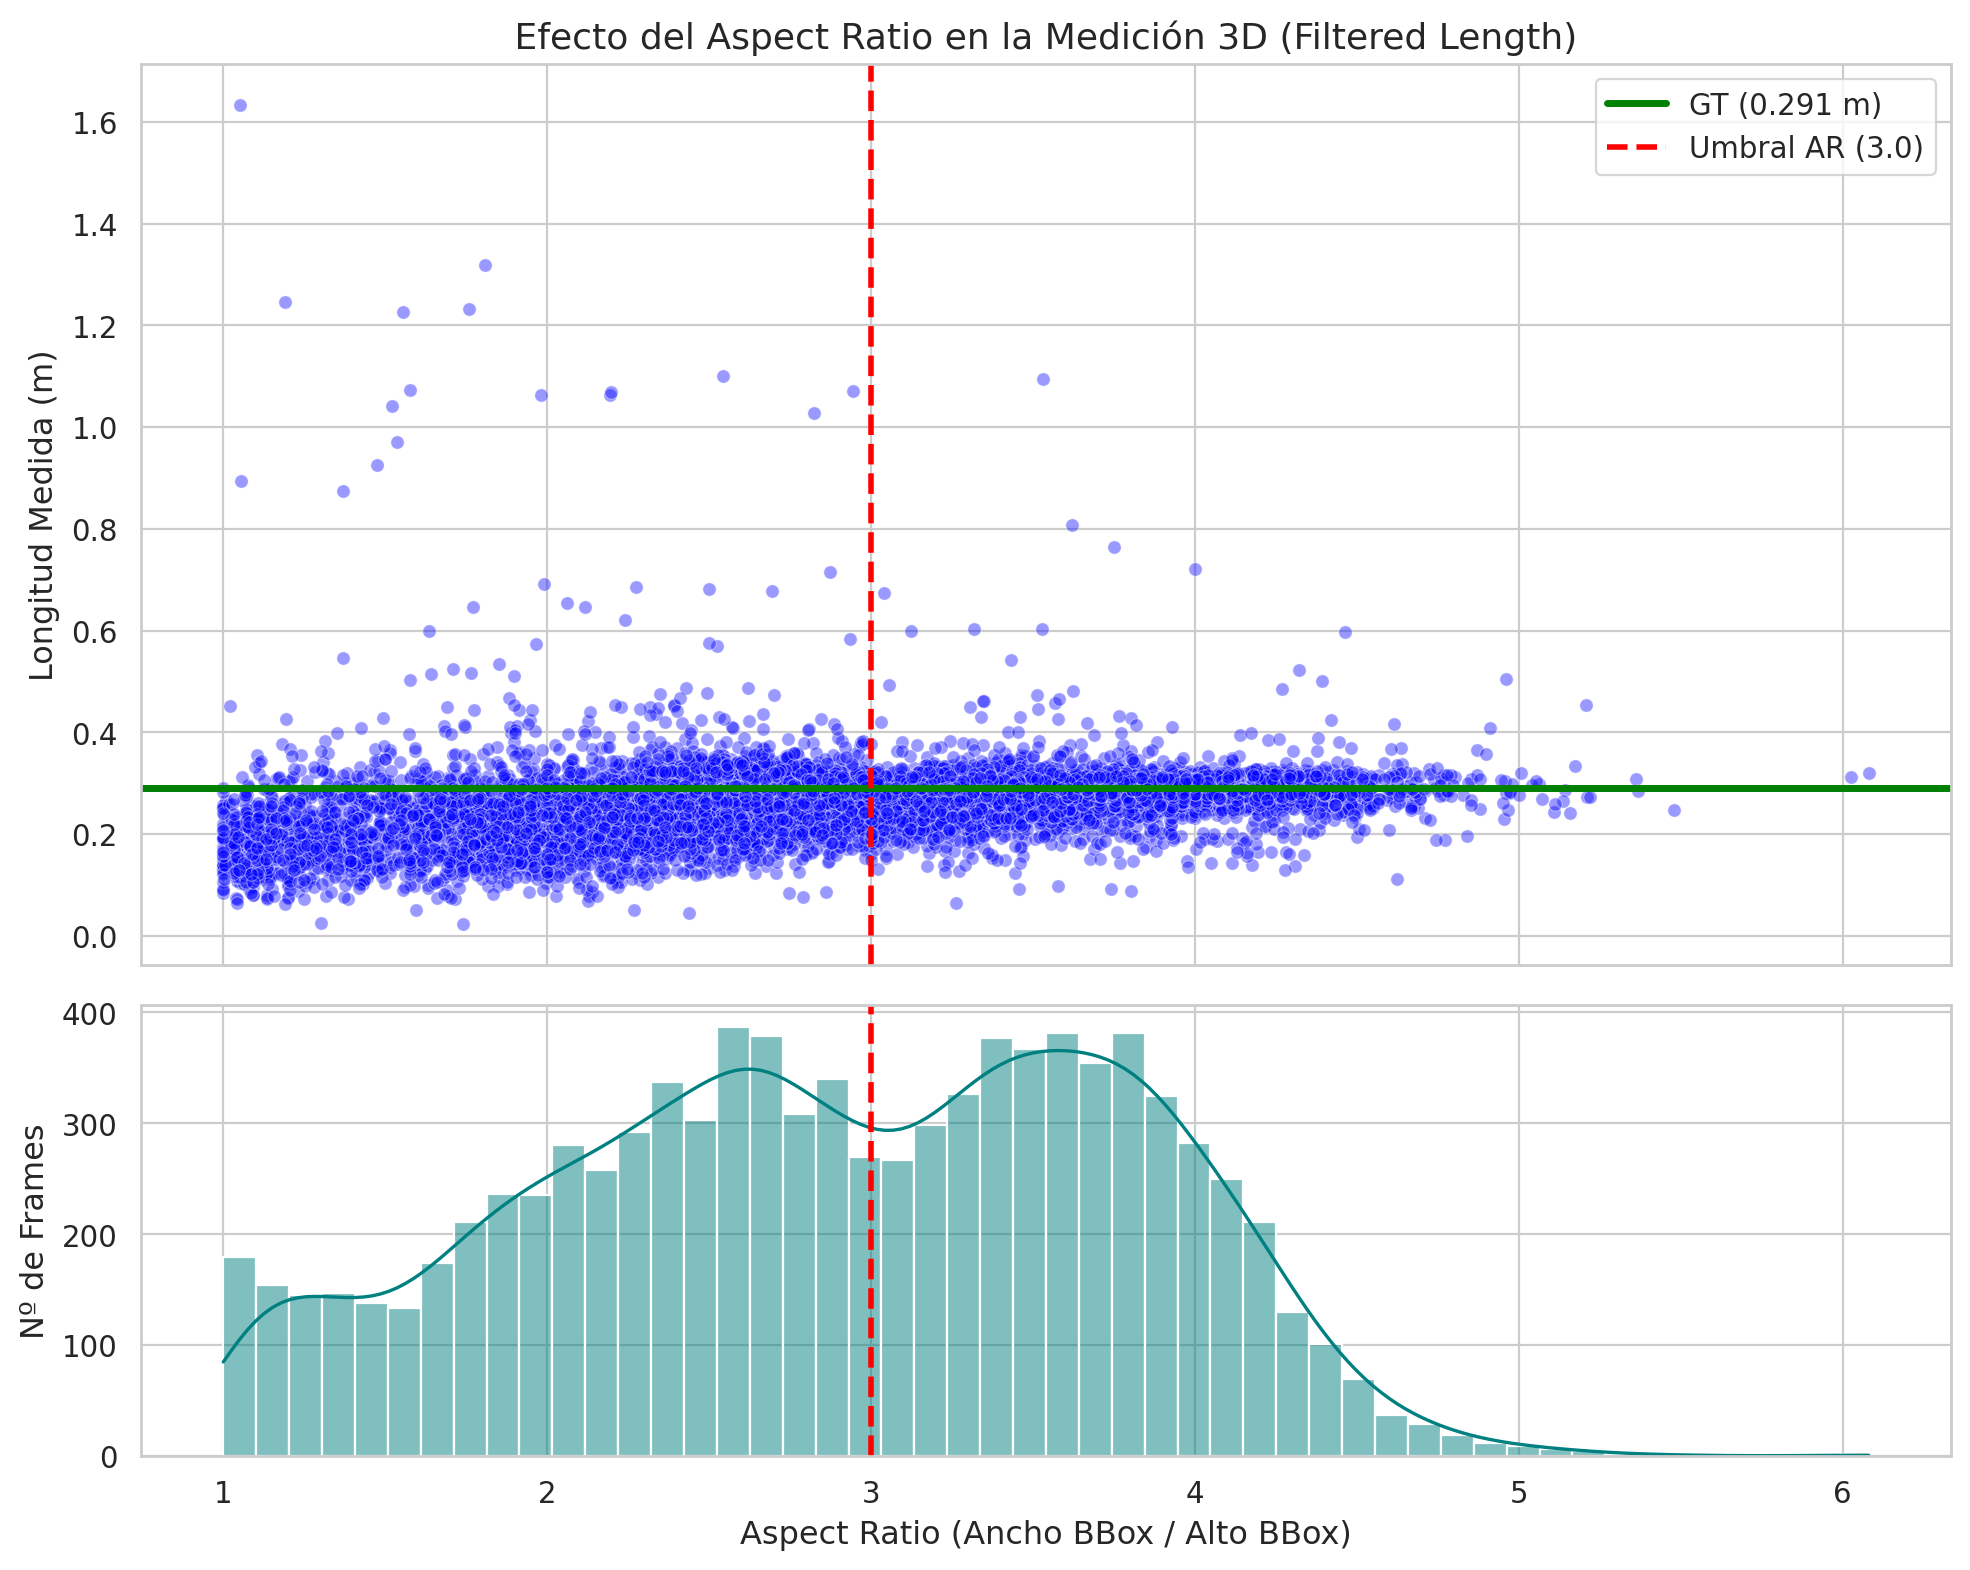

In [8]:
rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8)) 

#### ASPECT RATIO AND ANGLE THR IMPACT ON ERROR

Evaluating Angles: 100%|██████████| 6/6 [00:03<00:00,  1.69it/s]


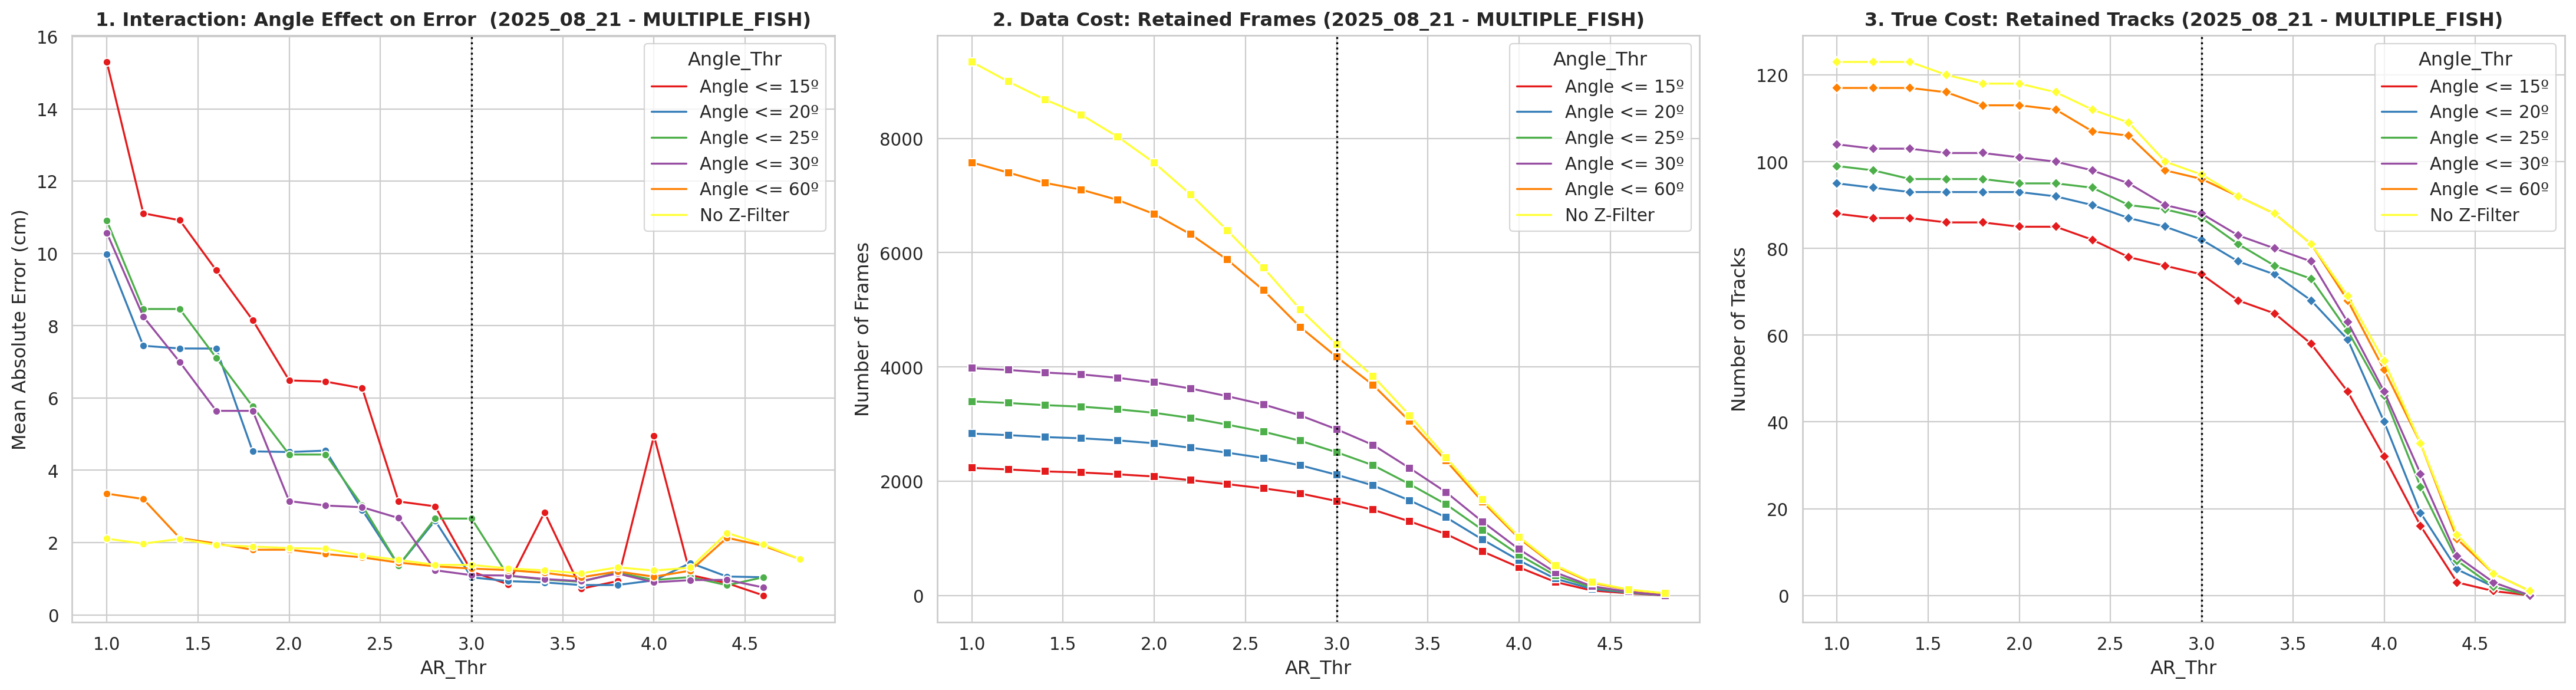

,Angle_Thr,AR_Thr,Error_cm,Frames,Tracks
0,Angle <= 15º,1.0,15.297258,2232,88
1,Angle <= 15º,1.2,11.110250,2205,87
2,Angle <= 15º,1.4,10.916366,2171,87
3,Angle <= 15º,1.6,9.532587,2152,86
4,Angle <= 15º,1.8,8.152343,2120,86
...,...,...,...,...,...
115,No Z-Filter,4.0,1.224298,1023,54
116,No Z-Filter,4.2,1.305668,526,35
117,No Z-Filter,4.4,2.264834,231,14
118,No Z-Filter,4.6,1.946513,104,5


In [9]:
rutils.plot_thresholds_interaction(df_raw_agg, optimal_ar=3, context=context_label)

##### RESULTS 

/home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/
--------------------------------------------------------
--------------------------------------------------------
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN without filters)             |  2.11 ± 2.98 cm |    9146 frames |   122 tracks
1. + Filter: No Borders                       |  2.11 ± 2.98 cm |    9146 frames |   122 tracks
2. + Filter: No Overlap                       |  1.89 ± 2.84 cm |    6469 frames |   113 tracks
3. + Filter: is_3D_complete                   |  1.89 ± 2.84 cm |    6375 frames |   113 tracks
4. + Filter: Aspect Ratio >= 3.0              |  1.22 ± 1.35 cm |    2857 frames |    86 tracks
5. + Filter: Z-Angle <= 30.0º                 |  1.23 ± 1.35 cm |    1866 frames |    74 tracks


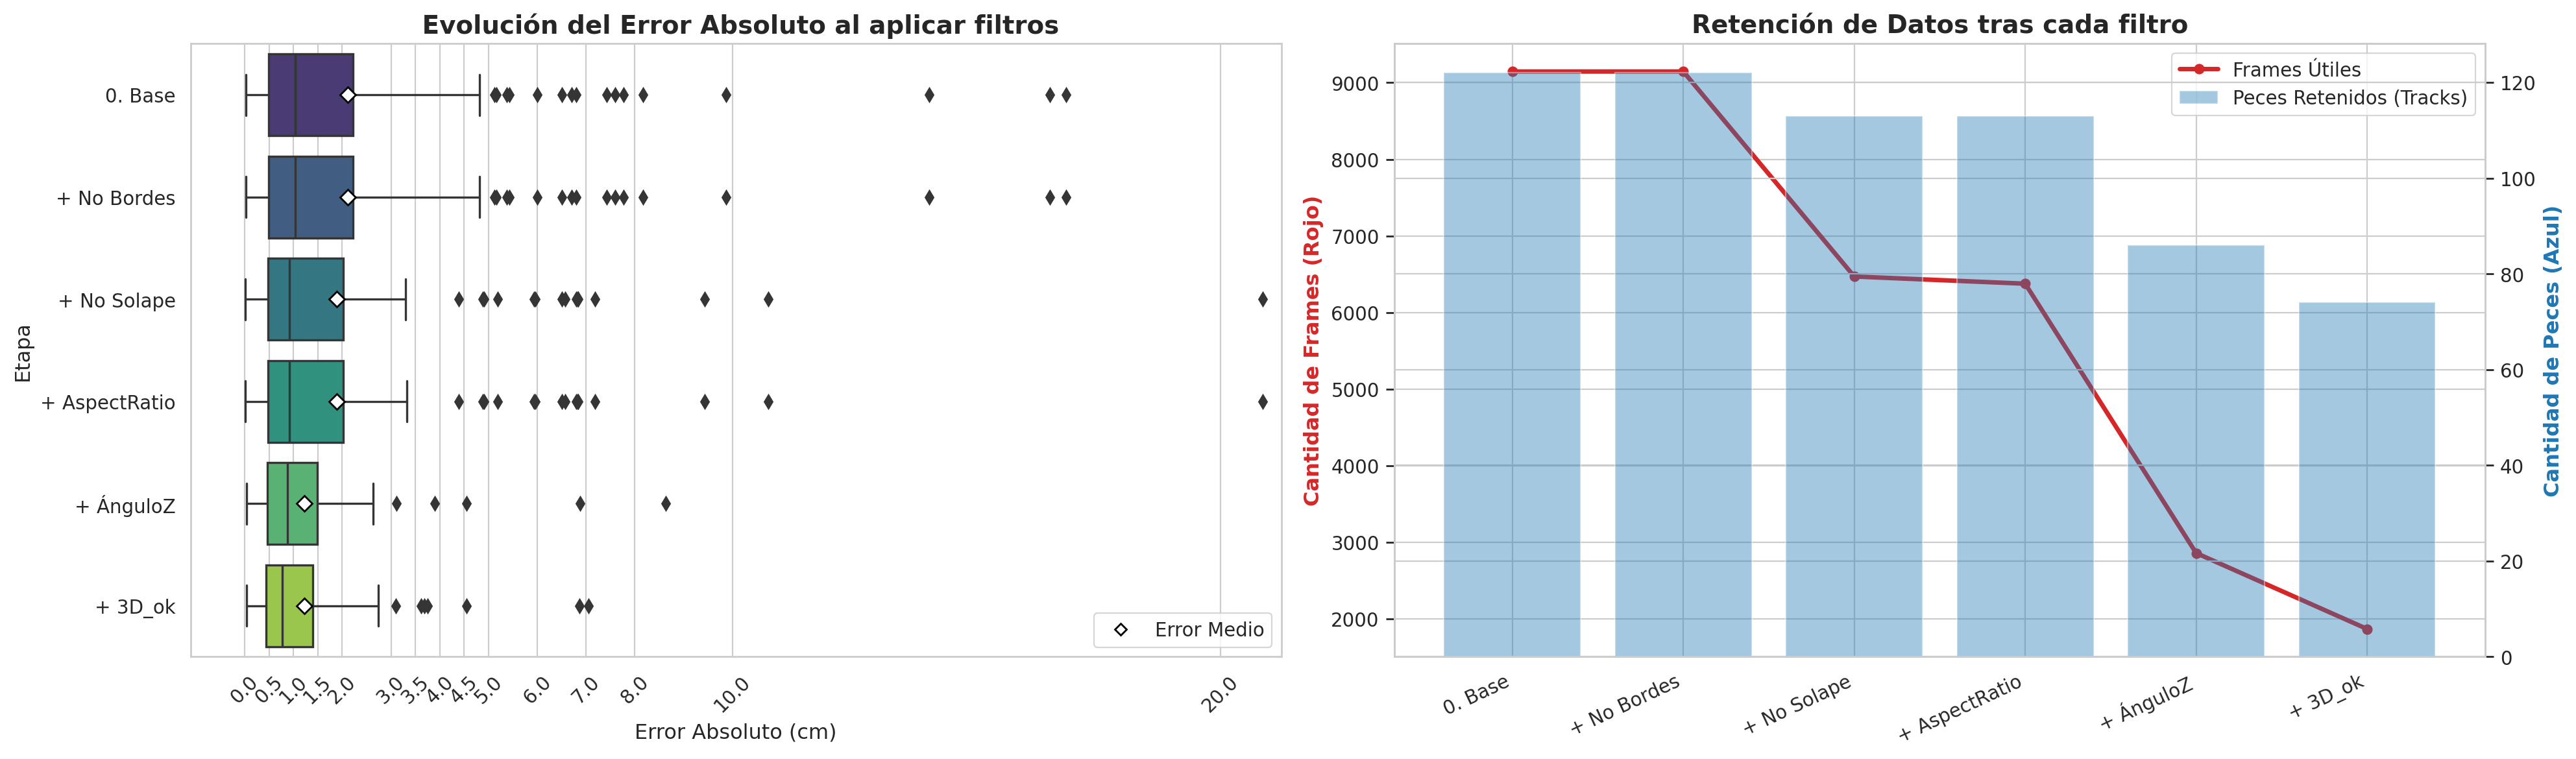

In [10]:

print(FOLDER_TO_ANALYSE)
print("--------------------------------------------------------")
print("--------------------------------------------------------")
# CALCULATE METRICS AND PLOTS
df_results={}

stages_dict, agg_stages_dict = rutils.plot_ablation_pipeline(
    df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, ANGLE_THR=ANGLE_THR   
)
 
# display(stages_dict)



##### SAVE RESULTS

In [11]:
#-----------------------------------------

# SAVE SUMMARY:
# 1. Extraer el DataFrame agregado de la última etapa (Todos los filtros aplicados)
# El nombre exacto de la llave depende de las variables que le pasaste
ultima_etapa_key = "5. + Filter: Z-Angle <= 30.0º"
df_final = agg_stages_dict[ultima_etapa_key].copy()

# 2. Eliminar todos los peces con track_id == -1 (Convertimos a string por si acaso)
df_final = df_final[~df_final['track_id'].astype(str).isin(['-1', '-1.0'])]

# 3. Exigir estrictamente que tengan MÁS de 5 frames de track válidos
df_final = df_final[df_final['n_frames_validos'] > 5]

# 4. Crear de nuevo el identificador único para que te sea fácil de leer
df_final['unique_track'] = df_final['video_day'].astype(str) + "_" + df_final['source_folder'].astype(str) + "_" + df_final['track_id'].astype(str)

# 5. Ordenar el dataframe (opcional, para que quede bonito)
df_final = df_final.sort_values(by=['video_day', 'source_folder', 'track_id']).reset_index(drop=True)

# Reordenar las columnas para que el identificador quede primero
cols = ['unique_track', 'video_day', 'source_folder', 'track_id', 'n_frames_validos', 'calculated_length_cm', 'gt_cm', 'abs_error_cm', 'mean_elevation_deg']
df_final = df_final[cols]

cprint(f"🎯 Peces finales válidos y filtrados: {len(df_final)}", "green", attrs=["bold"])
display(df_final)

# ==========================================================
# 💾 GUARDAR 1: El listado completo de peces (Summary)
# ==========================================================
summary_path = os.path.join(csv_out_path,  day_code+"_"+group+"_filtered_measures_summary.csv")
df_final.to_csv(summary_path, index=False)
cprint(f"✅ Listado de tracks guardado en: {summary_path}", "green")

# ==========================================================
# 📊 CALCULAR Y GUARDAR 2: Las Métricas Globales (Metrics)
# ==========================================================
metrics_data = {
    "Total_Peces_Retenidos": [len(df_final)],
    "Promedio_Frames_Validos": [round(df_final['n_frames_validos'].mean(), 1) if not df_final.empty else 0],
    "Error_Absoluto_Medio_cm": [round(df_final['abs_error_cm'].mean(), 2) if not df_final.empty else 0],
    "Desviacion_Estandar_Error_cm": [round(df_final['abs_error_cm'].std(), 2) if not df_final.empty else 0]
}

df_metrics = pd.DataFrame(metrics_data)


print("\n📊 TABLA DE MÉTRICAS GLOBALES:")
display(df_metrics)

metrics_path = os.path.join(csv_out_path,  day_code+"_"+group+"_filtered_measures_metrics.csv")
df_metrics.to_csv(metrics_path, index=False)
cprint(f"✅ Métricas globales guardadas en: {metrics_path}", "green")

🎯 Peces finales válidos y filtrados: 74


,unique_track,video_day,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
0,2025_08_21_10-01-53_0_compressed-r201-end_1,2025_08_21,10-01-53_0_compressed-r201-end,1,59.0,31.208944,29.1,2.108944,3.402430
1,2025_08_21_10-01-53_0_compressed-r201-end_4,2025_08_21,10-01-53_0_compressed-r201-end,4,14.0,36.844358,32.3,4.544358,3.907754
2,2025_08_21_10-01-53_0_compressed-r201-end_18,2025_08_21,10-01-53_0_compressed-r201-end,18,31.0,28.425580,29.1,0.674420,-7.608901
3,2025_08_21_10-07-59_0-r50-end_6,2025_08_21,10-07-59_0-r50-end,6,24.0,27.702858,29.1,1.397142,-0.177364
4,2025_08_21_10-07-59_0-r50-end_9,2025_08_21,10-07-59_0-r50-end,9,21.0,31.856798,32.3,0.443202,-7.936478
...,...,...,...,...,...,...,...,...,...
69,2025_08_21_13-23-54_0_compressed-r450-524_1,2025_08_21,13-23-54_0_compressed-r450-524,1,19.0,33.776322,32.3,1.476322,7.832630
70,2025_08_21_13-23-54_0_compressed-r450-524_2,2025_08_21,13-23-54_0_compressed-r450-524,2,25.0,27.355601,26.6,0.755601,-4.799788
71,2025_08_21_13-23-54_0_compressed-r450-524_3,2025_08_21,13-23-54_0_compressed-r450-524,3,20.0,28.708623,29.1,0.391377,2.104248
72,2025_08_21_13-23-54_0_compressed-r602-end_1,2025_08_21,13-23-54_0_compressed-r602-end,1,28.0,28.600974,29.1,0.499026,-3.697027


✅ Listado de tracks guardado en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish/2025_08_21_multiple_fish_filtered_measures_summary.csv

📊 TABLA DE MÉTRICAS GLOBALES:


,Total_Peces_Retenidos,Promedio_Frames_Validos,Error_Absoluto_Medio_cm,Desviacion_Estandar_Error_cm
0,74,24.7,1.23,1.35


✅ Métricas globales guardadas en: /home/slimbook/fish_sizing/ARTICLE/DATASET_2/2025_08_21/multiple_fish/2025_08_21_multiple_fish_filtered_measures_metrics.csv
